### [Understanding Options Pricing](https://medium.com/financial-engineering/understanding-options-pricing-the-greeks-explained-d33ebf4b70d9)
> [Fundamentals of Options: From Simple Payoffs to Complex Strategies](https://simplified-zone.com/fundamentals-of-options-from-simple-payoffs-to-complex-strategies/)

> _For a **Call Option**: As the stock price rises, the call becomes more valuable._

> _For a **Put Option**: As the stock price rises, the put becomes less valuable._

This sensitivity is known as **Delta**. Delta measures how much an option’s price is expected to change for a $1 move in the underlying stock. It ranges from 0 to 1 for calls and -1 to 0 for puts.

In [1]:
import warnings
warnings.filterwarnings('ignore')

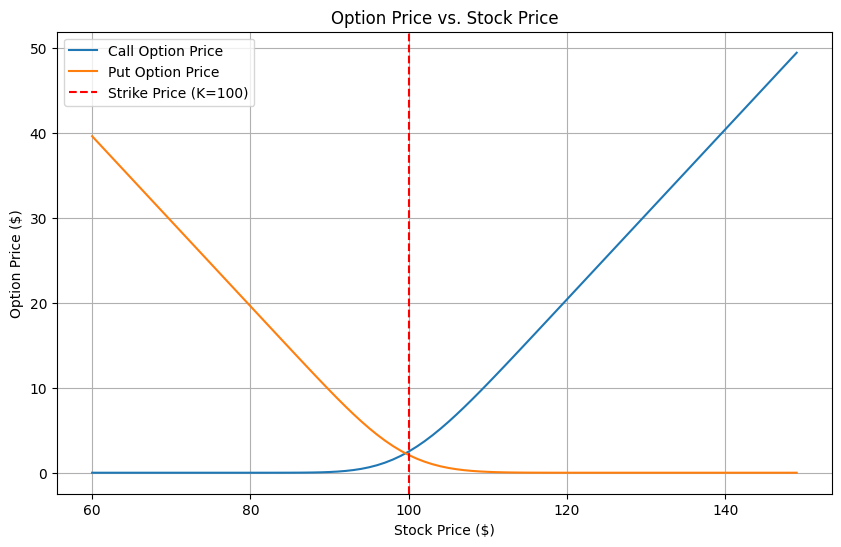

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Black-Scholes formula for European options
def black_scholes(option_type, s0, k, t, sigma, r):
    """
    Calculates the price of a European call or put option.

    option_type: 'call' or 'put'
    s0: Initial stock price
    k: Strike price
    t: Time to expiration in years
    sigma: Volatility of the stock
    r: Risk-free interest rate
    """
    d1 = (np.log(s0 / k) + (r + 0.5 * sigma ** 2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)

    if option_type == 'call':
        price = s0 * norm.cdf(d1) - k * np.exp(-r * t) * norm.cdf(d2)
    elif option_type == 'put':
        price = k * np.exp(-r * t) * norm.cdf(-d2) - s0 * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option type. Choose 'call' or 'put'.")

    return price

# Define a range of stock prices to analyze
stock_prices = np.arange(60, 150, 1)

# Initialize lists to store option prices
call_prices = []
put_prices = []

# Calculate option prices for each stock price
for price in stock_prices:
    call_price = black_scholes('call', s0=price, k=100, t=30/365.0, sigma=0.20, r=0.05)
    put_price = black_scholes('put', s0=price, k=100, t=30/365.0, sigma=0.20, r=0.05)
    call_prices.append(call_price)
    put_prices.append(put_price)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, call_prices, label='Call Option Price')
plt.plot(stock_prices, put_prices, label='Put Option Price')
plt.xlabel('Stock Price ($)')
plt.ylabel('Option Price ($)')
plt.title('Option Price vs. Stock Price')
plt.axvline(x=100, color='r', linestyle='--', label='Strike Price (K=100)')
plt.grid(True)
plt.legend()
plt.show()

**Gamma** measures the rate of change of Delta. Gamma is highest for at-the-money (ATM) options, meaning their sensitivity to stock price moves is the most dynamic.

#### Dependency on Time: The Inexorable Melt of Theta

An option's value has two components: *intrinsic value* (how much it's in-the-money) and *extrinsic value* (also known as time value).

Extrinsic value is the premium you pay for the possibility that the option will become profitable by expiration.

This decay in an option's price due to the passage of time is called **_Theta_**. It is often referred to as the "time melt" or "time decay" of an option.

*Theta* is the enemy of the option buyer and the friend of the option seller.
The rate of decay is not linear. It accelerates as the expiration date approaches.

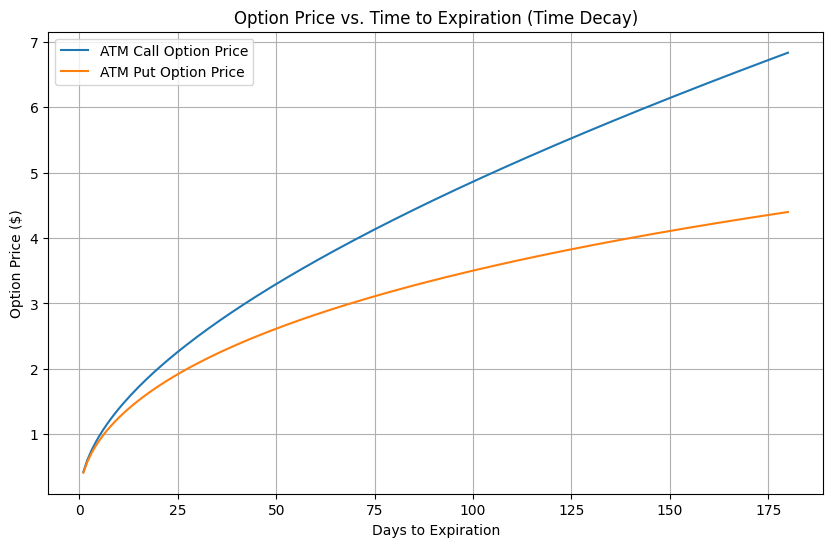

In [3]:
# Define a range of days to expiration
days_to_expiration = np.arange(1, 181, 1)

call_prices_time = []
put_prices_time = []

# Calculate option prices for each time to expiration
for days in days_to_expiration:
    # Convert days to years for the formula
    time_in_years = days / 365.0
    call_price = black_scholes('call', s0=100, k=100, t=time_in_years, sigma=0.20, r=0.05)
    put_price = black_scholes('put', s0=100, k=100, t=time_in_years, sigma=0.20, r=0.05)
    call_prices_time.append(call_price)
    put_prices_time.append(put_price)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(days_to_expiration, call_prices_time, label='ATM Call Option Price')
plt.plot(days_to_expiration, put_prices_time, label='ATM Put Option Price')
plt.xlabel('Days to Expiration')
plt.ylabel('Option Price ($)')
plt.title('Option Price vs. Time to Expiration (Time Decay)')
plt.grid(True)
plt.legend()
plt.show()

#### Dependency on Volatility: The Fuel of Vega

**Volatility** is the magnitude of a stock's price swings. Implied volatility is the market's consensus forecast of how volatile the stock will be in the future. It's a key ingredient in an option's price because higher volatility means a greater chance of a large price move.

This sensitivity of an option's price to a 1% change in implied volatility is called **Vega**.

- Vega is positive for both calls and puts.
- Option buyers are "_long Vega_" (they benefit from increasing volatility).
- Option sellers are "_short Vega_" (they benefit from decreasing volatility).

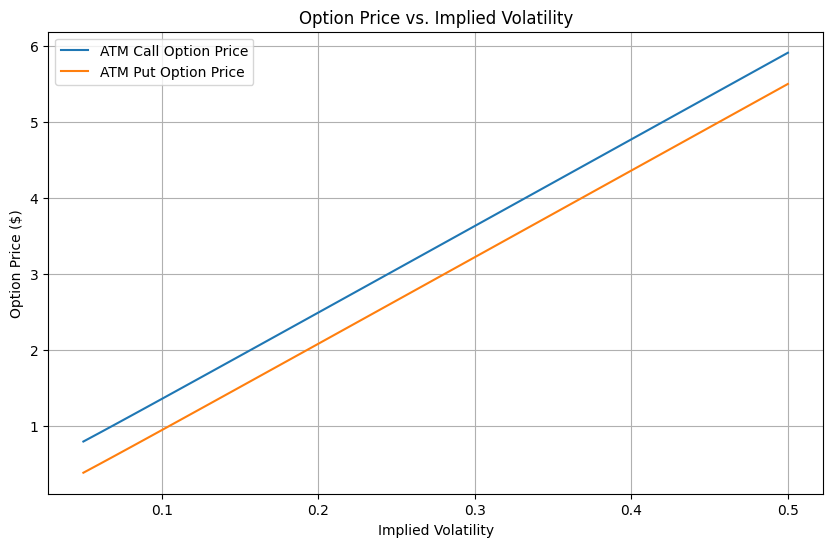

In [4]:
# Define a range of volatility values
volatilities = np.arange(0.05, 0.51, 0.01) # 5% to 50%

call_prices_vol = []
put_prices_vol = []

# Calculate option prices for each volatility level
for vol in volatilities:
    call_price = black_scholes('call', s0=100, k=100, t=30/365.0, sigma=vol, r=0.05)
    put_price = black_scholes('put', s0=100, k=100, t=30/365.0, sigma=vol, r=0.05)
    call_prices_vol.append(call_price)
    put_prices_vol.append(put_price)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(volatilities, call_prices_vol, label='ATM Call Option Price')
plt.plot(volatilities, put_prices_vol, label='ATM Put Option Price')
plt.xlabel('Implied Volatility')
plt.ylabel('Option Price ($)')
plt.title('Option Price vs. Implied Volatility')
plt.grid(True)
plt.legend()
plt.show()

#### Dependency on Interest Rates: The Subtle Hand of Rho

 The sensitivity of an option's price to a 1% change in the risk-free interest rate is known as **Rho**.

- **Calls**: Higher interest rates make call options more valuable.
- **Puts**: Higher interest rates make put options less valuable.

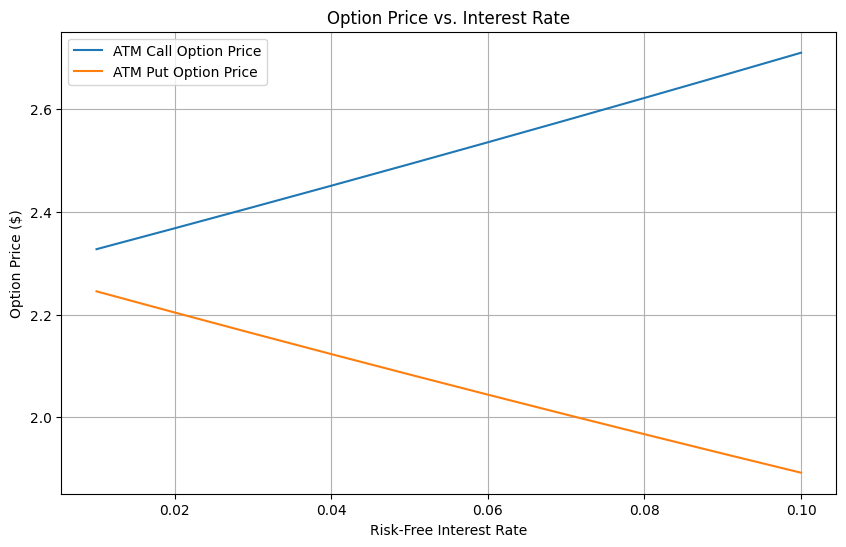

In [5]:
# Define a range of interest rates
interest_rates = np.arange(0.01, 0.11, 0.01) # 1% to 10%

call_prices_rate = []
put_prices_rate = []

# Calculate option prices for each interest rate
for rate in interest_rates:
    call_price = black_scholes('call', s0=100, k=100, t=30/365.0, sigma=0.20, r=rate)
    put_price = black_scholes('put', s0=100, k=100, t=30/365.0, sigma=0.20, r=rate)
    call_prices_rate.append(call_price)
    put_prices_rate.append(put_price)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(interest_rates, call_prices_rate, label='ATM Call Option Price')
plt.plot(interest_rates, put_prices_rate, label='ATM Put Option Price')
plt.xlabel('Risk-Free Interest Rate')
plt.ylabel('Option Price ($)')
plt.title('Option Price vs. Interest Rate')
plt.grid(True)
plt.legend()
plt.show()